In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import importlib

In [112]:
import data_set

data = 'D:\Documents\github\diabetes_prediction\diabetes_prediction_system\data_set\diabetes.csv'

df = pd.read_csv(data)

In [113]:
import basic_inspection

ba = basic_inspection.Basics(df)

ba.col_row()
print()
ba.describe()

total columns: 9
total row is: 768

describe of data
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760

In [4]:
ba.data_type()

Pregnancies data type :int64
Glucose data type :int64
BloodPressure data type :int64
SkinThickness data type :int64
Insulin data type :int64
BMI data type :float64
DiabetesPedigreeFunction data type :float64
Age data type :int64
Outcome data type :int64


In [5]:
ba.missing_val()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64



In [8]:
# check is values is having '0' 
import data_cleaning as dc

importlib.reload(dc)

<module 'data_cleaning' from 'd:\\Documents\\github\\diabetes_prediction\\diabetes_prediction_system\\data_cleaning.py'>

In [121]:
num = dc.Numberic(df)

num.zeros()

missing/zero Pregnancies : 111, percentage : 14%
missing/zero Glucose : 5, percentage : 1%
missing/zero BloodPressure : 35, percentage : 5%
missing/zero SkinThickness : 227, percentage : 30%
missing/zero Insulin : 374, percentage : 49%
missing/zero BMI : 11, percentage : 1%
missing/zero DiabetesPedigreeFunction : 0, percentage : 0%
missing/zero Age : 0, percentage : 0%
missing/zero Outcome : 500, percentage : 65%


**Conclusion**: **data missing**

***Pregnancies***: we can ignore this column because any patient can have Pregnancies zero and also ignore outcome column it is a output column '0','1'

***remaining columns?**: we need focus on 

'Glucose zeros', 

'BloodPressure zeros, 

'SkinThickness zeros',

'Insulin zeros', 

'BMI zeros', 



**Handling missing values**

skewness : -1.8436079833551302
Mean : 69.10546875
Median : 72.0
Mode : 0    70
Name: BloodPressure, dtype: int64


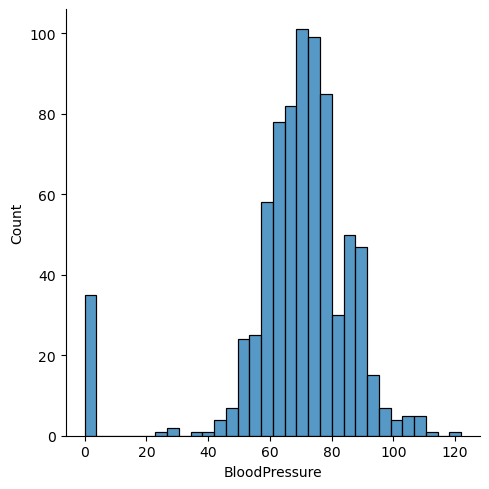

In [ ]:
# column: 'BloodPressure

num.distri_plot('BloodPressure')
num.mean('BloodPressure')
num.median('BloodPressure')
num.mode('BloodPressure')

column : 'BloodPressure' , almost normal distribution and also 5% data is missing we can fill this using mean

fill zeros : mean

skewness : 0.17375350179188992
Mean : 120.89453125
Median : 117.0
Mode : 0     99
1    100
Name: Glucose, dtype: int64


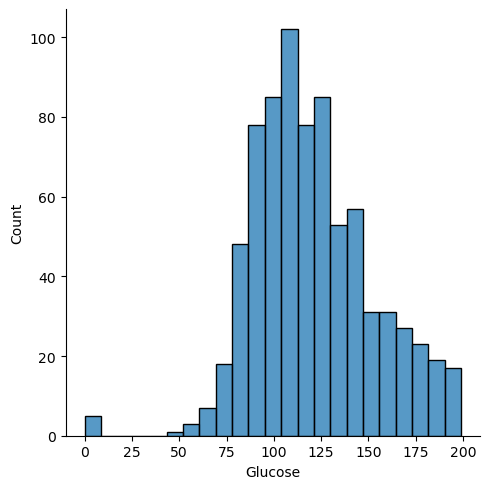

In [99]:
num.distri_plot('Glucose')
num.mean('Glucose')
num.median('Glucose')
num.mode('Glucose')

col : 'Glucose' normal distribution , missing only 1%

fill zeros : mean

skewness : -0.42898158845356543
Mean : 31.992578124999998
Median : 32.0
Mode : 0    32.0
Name: BMI, dtype: float64


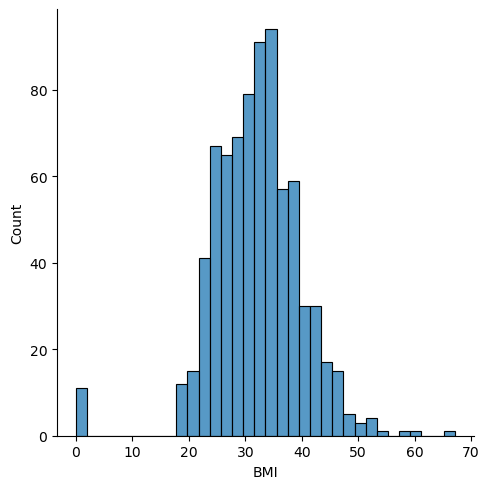

In [101]:
num.distri_plot('BMI')
num.mean('BMI')
num.median('BMI')
num.mode('BMI')

column : 'BMI' almost normal distribuion 

fill zeros : mean

skewness : 0.10937249648187608
Mean : 20.536458333333332
Median : 23.0
Mode : 0    0
Name: SkinThickness, dtype: int64


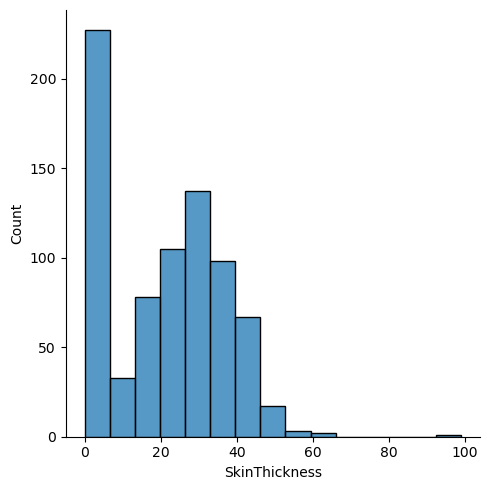

In [103]:
num.distri_plot('SkinThickness')
num.mean('SkinThickness')
num.median('SkinThickness')
num.mode('SkinThickness')

column : 'Skin' , normal distribution but I need to fill this using knn because of 30% of data is missing

fill zeros : knn 

skewness : 2.272250858431574
Mean : 79.79947916666667
Median : 30.5
Mode : 0    0
Name: Insulin, dtype: int64


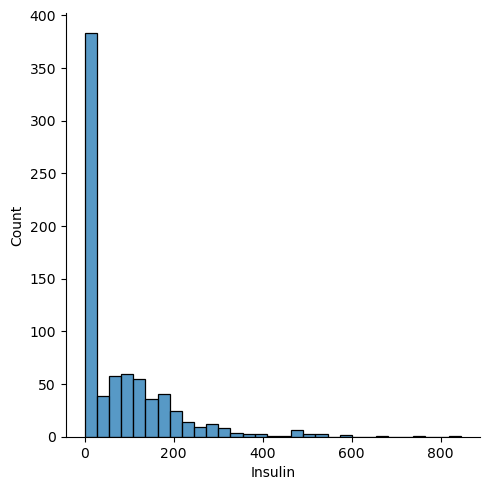

In [122]:
# column : Insulin

num.distri_plot('Insulin')
num.mean('Insulin')
num.median('Insulin')
num.mode('Insulin')

colum : 'Insulin' , **49%** data is missing, we can not use normal tendency for fillin missing values, we can use knn 

**what we can do**
method 1 : knn imputing 
method 2 :creating two models:

        Model 1
            Keep Insulin.
            Impute missing values (KNN or median).

        Model 2
            Drop Insulin.
        
        then comparting with both models where model 2 is giving similar result then we can use model 2, else model 1 

**filling missing values**

In [ ]:
# fill col : blood pressure with 'mean' because distribution is normal

fill_zero = dc.Filling_numeric(df)

# column : BP
temp_df = fill_zero.fill_mean_(df,'BloodPressure') 

In [ ]:
# columns : glucose

temp_df = fill_zero.fill_mean_(temp_df,'Glucose')

In [126]:
# column : BMI

temp_df = fill_zero.fill_mean_(temp_df,'BMI')

In [ ]:
# Saving partially cleaned progress

temp_df.to_csv('diabetes_interim.csv', index=False)

filling col :'Insulin' and 'Skin'

In [132]:
from sklearn.impute import KNNImputer

# Replace only these two columns

temp_df["SkinThickness"] = temp_df["SkinThickness"].replace(0, np.nan)
temp_df["Insulin"] = temp_df["Insulin"].replace(0, np.nan)

# Apply KNN
imputer = KNNImputer(n_neighbors=5)

temp_df = pd.DataFrame(
    imputer.fit_transform(temp_df),
    columns=temp_df.columns
)

# Copy only the two columns back
df["SkinThickness"] = temp_df["SkinThickness"]
df["Insulin"] = temp_df["Insulin"]

In [136]:
cross_check = dc.Filling_numeric(temp_df)

cross_check.zeros()

missing/zero Pregnancies : 111, percentage : 14%
missing/zero Glucose : 0, percentage : 0%
missing/zero BloodPressure : 0, percentage : 0%
missing/zero SkinThickness : 0, percentage : 0%
missing/zero Insulin : 0, percentage : 0%
missing/zero BMI : 0, percentage : 0%
missing/zero DiabetesPedigreeFunction : 0, percentage : 0%
missing/zero Age : 0, percentage : 0%
missing/zero Outcome : 500, percentage : 65%


saving final dataset

In [ ]:
# final clean data
temp_df.to_csv('diabetes_cleanned_data.csv',index=False)

**Removing Outliers**

In [13]:
data = 'D:\Documents\github\diabetes_prediction\diabetes_prediction_system\data_set\diabetes_interim_2.csv'

In [42]:
df_2 = pd.read_csv(data)

importlib.reload(dc)

<module 'data_cleaning' from 'd:\\Documents\\github\\diabetes_prediction\\diabetes_prediction_system\\data_cleaning.py'>

In [43]:
outlier = dc.Outlier(df_2)

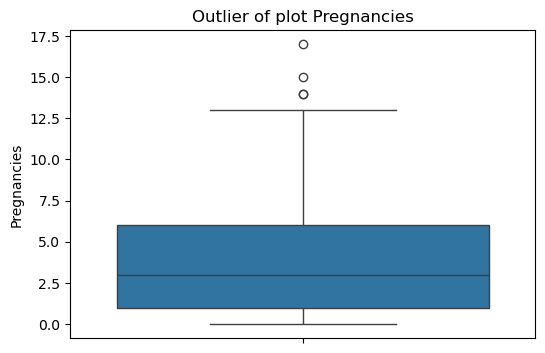

column : Pregnancies
lower count: 0
upper cnt: 4
total outlier count: 4


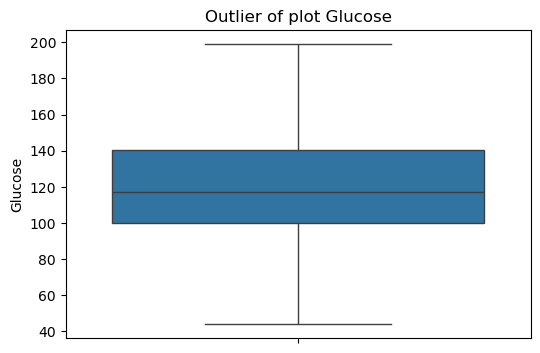

column : Glucose
lower count: 0
upper cnt: 0
total outlier count: 0


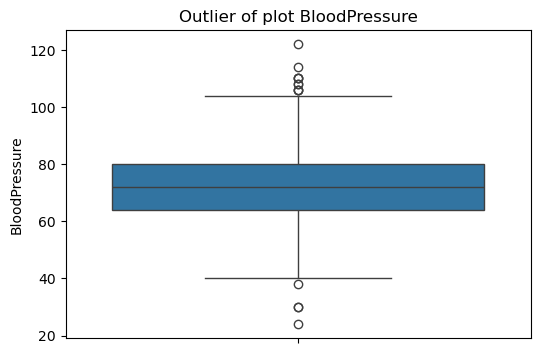

column : BloodPressure
lower count: 4
upper cnt: 10
total outlier count: 14


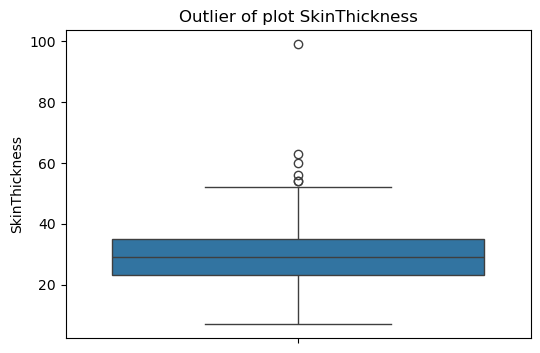

column : SkinThickness
lower count: 0
upper cnt: 6
total outlier count: 6


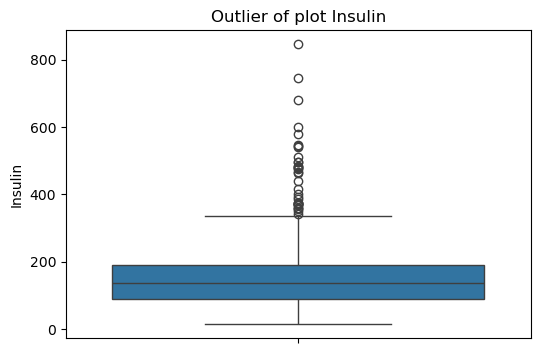

column : Insulin
lower count: 0
upper cnt: 35
total outlier count: 35


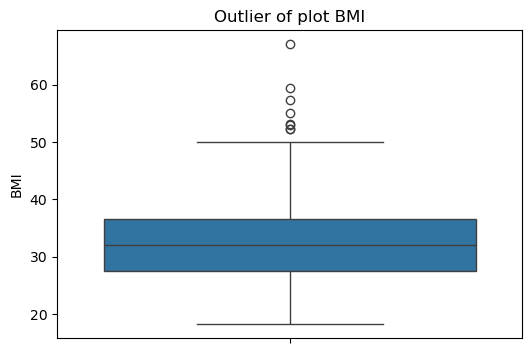

column : BMI
lower count: 0
upper cnt: 8
total outlier count: 8


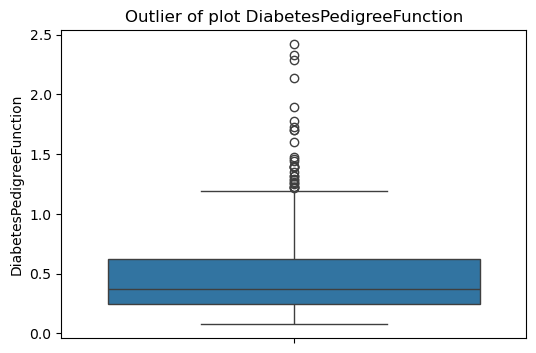

column : DiabetesPedigreeFunction
lower count: 0
upper cnt: 29
total outlier count: 29


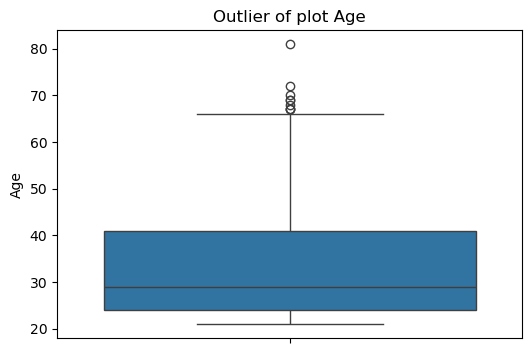

column : Age
lower count: 0
upper cnt: 9
total outlier count: 9


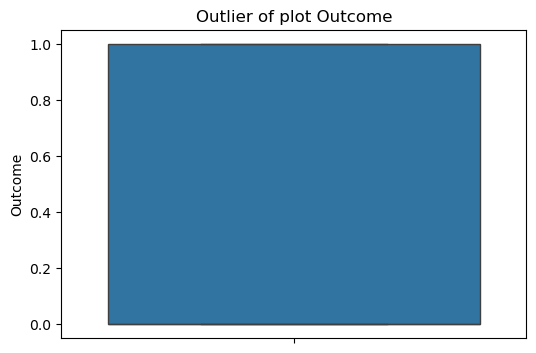

column : Outcome
lower count: 0
upper cnt: 0
total outlier count: 0


In [44]:
# column : Pregnancies

for column in df_2.columns:
    outlier.check_outlier(column)
    outlier.count_outlier(column)

***Conclusion: Outlier Analysis***

After analyzing all the columns using the IQR method, only a small number of outliers were detected in most features. These outliers represent medically valid observations rather than data entry errors. Therefore, no outliers were removed from the dataset.

***Insulin:***
The `Insulin` column originally contained approximately 49% missing values. These missing values were imputed using the KNN Imputer. Since the imputed values may influence the distribution and outlier detection, removing the detected insulin outliers could result in the loss of useful information. Therefore, the insulin outliers were also retained.

Overall, all detected outliers were kept because they are valid patient observations and may contain important information for building the machine learning model.

In [ ]:
# final clean data
#temp_df.to_csv('diabetes_cleanned_data.csv',index=False)

converting  columns of 'Age', 'Pregnancies', 'Outcome' data type float to int 

In [36]:
# again reading the DataFrame

data = 'D:\Documents\github\diabetes_prediction\diabetes_prediction_system\data_set\diabetes_interim_2.csv'
df = pd.read_csv(data)


df.head(3)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148.0,72.0,35.0,169.0,33.6,0.627,50.0,1.0
1,1.0,85.0,66.0,29.0,58.6,26.6,0.351,31.0,0.0
2,8.0,183.0,64.0,25.8,164.6,23.3,0.672,32.0,1.0


In [37]:
import importlib
import data_cleaning

importlib.reload(data_cleaning)

dc = data_cleaning.Type_conv(df)


In [38]:
# converting
# column : Age
dc.to_int('Age')

Age is converted to int


In [39]:
# column : Pregnancies
dc.to_int('Pregnancies')

Pregnancies is converted to int


In [40]:
# column : Outcome
dc.to_int('Outcome')

Outcome is converted to int


In [42]:
df.head(3)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,169.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,58.6,26.6,0.351,31,0
2,8,183.0,64.0,25.8,164.6,23.3,0.672,32,1


now the 'diabetes' data are cleanned 

cleanning involves

    filling null values
    identified outliers
    converting the data type

saving cleanned data as 'diabetes_cleanned_data.csv' file

In [ ]:
#df.to_csv('diabetes_cleanned_data.csv',index=False)